# 02 — Process Performance Map (Camargo DomesticDeclarations)

Port of the henryk `02_process_performance_map` notebook, adapted for the Camargo `FullShared_Join_LSTM` baseline trained with the **paper-faithful n-gram=15 loader** (see `train_camargo_LSTM_ngram15.ipynb`). The earlier U-ED-LSTM-style windowing gave the model mostly EOS targets and no signal at short prefixes — this variant emits one training sample per time-step with the actual next activity as target.

- **Node label**: activity; color ∝ overall per-source-activity accuracy.
- **Edge label**: `correct / total` predictions for that directly-follows transition.
- **Edge color**: per-transition accuracy (green = high, red = low).

The Camargo model is a single-step next-activity predictor; we iterate prefixes (length 1..L-1) and call it once per prefix to build the performance map.

In [7]:
import sys
from pathlib import Path

# Locate project root and add needed paths
_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir() and (_current / 'encoded_data').is_dir():
        break
    _current = _current.parent
_camargo_dir = _current / 'src' / 'interpretability' / 'notebooks' / 'camargo'
for p in [_current, _current / 'src', _camargo_dir]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import _camargo_utils as utils

project_root = _current
SPEC = utils.DOMESTIC_DECLARATIONS

model = utils.load_camargo_model(project_root, SPEC)
dataset = utils.load_test_dataset(project_root, SPEC)
# With ngram_size set, use that at inference so the input shape matches training.
window = SPEC.ngram_size or utils.compute_window(dataset)
predictor = utils.CamargoPredictor(model, SPEC, window)
print(f'Loaded Camargo {SPEC.name} model | window={window} | vocab={predictor.n_classes} classes | |test|={len(dataset)}')

Data set categories:  ([('Activity', 10, {'APPROVED': 1, 'EOS': 2, 'FINAL_APPROVED': 3, 'FOR_APPROVAL': 4, 'Payment Handled': 5, 'REJECTED': 6, 'Request Payment': 7, 'SAVED': 8, 'SUBMITTED': 9}), ('Resource', 4, {'EOS': 1, 'STAFF MEMBER': 2, 'SYSTEM': 3})], [('case_elapsed_time', 1, {})])
Model input features:  [['Activity', 'Resource'], ['case_elapsed_time']]


Embeddings:  ModuleList(
  (0): Embedding(10, 6)
  (1): Embedding(4, 3)
)
Total embedding feature size:  9
Input feature size:  10
Cells hidden size:  50
Number of LSTM layer:  1
Loaded Camargo DomesticDeclarations model | window=15 | vocab=10 classes | |test|=15471


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


In [8]:
records = utils.collect_prefix_predictions(predictor, dataset, progress=True, include_end=True)
print(f'Collected {len(records)} prefix predictions')
print(f"Overall accuracy: {sum(r['correct'] for r in records) / len(records) * 100:.1f}%")

Collected 11271 prefix predictions
Overall accuracy: 88.8%


In [9]:
# --- Overall accuracy summary ---
from collections import defaultdict
import pandas as pd

n_total = len(records)
n_correct = sum(1 for r in records if r['correct'])
overall = n_correct / n_total if n_total else 0.0
print(f'Overall next-activity accuracy: {n_correct}/{n_total} = {overall:.4f} ({overall*100:.2f}%)')

by_plen = defaultdict(lambda: {'total': 0, 'correct': 0})
for r in records:
    by_plen[r['prefix_length']]['total'] += 1
    by_plen[r['prefix_length']]['correct'] += int(r['correct'])
rows = [{'prefix_length': pl, 'correct': v['correct'], 'total': v['total'],
         'accuracy': v['correct'] / v['total']}
        for pl, v in sorted(by_plen.items())]
print('\nPer prefix-length:')
print(pd.DataFrame(rows).to_string(index=False))

if n_total and 'confidence' in records[0]:
    mean_conf = sum(r['confidence'] for r in records) / n_total
    print(f'\nMean top-1 confidence: {mean_conf*100:.2f}%')


Overall next-activity accuracy: 10011/11271 = 0.8882 (88.82%)

Per prefix-length:
 prefix_length  correct  total  accuracy
             1     1624   2100  0.773333
             2     1491   2071  0.719942
             3     2008   2070  0.970048
             4     1989   2021  0.984166
             5     1677   1738  0.964902
             6      684    709  0.964739
             7      187    196  0.954082
             8      170    178  0.955056
             9      100    106  0.943396
            10       40     40  1.000000
            11       21     21  1.000000
            12       13     13  1.000000
            13        3      4  0.750000
            14        1      1  1.000000
            15        1      1  1.000000
            16        1      1  1.000000
            17        1      1  1.000000

Mean top-1 confidence: 88.61%


In [10]:
import pandas as pd
from collections import defaultdict

# Per-transition stats (source activity, actual next activity) -> total / correct
stats = defaultdict(lambda: {'total': 0, 'correct': 0})
for r in records:
    key = (r['current_activity'], r['actual_next_activity'])
    stats[key]['total'] += 1
    stats[key]['correct'] += int(r['correct'])

# Per-source accuracy (node color)
node_stats = defaultdict(lambda: {'total': 0, 'correct': 0})
for r in records:
    node_stats[r['current_activity']]['total'] += 1
    node_stats[r['current_activity']]['correct'] += int(r['correct'])

rows = []
for (src, tgt), s in stats.items():
    rows.append({'source': src, 'target': tgt, 'correct': s['correct'], 'total': s['total'],
                 'accuracy': s['correct'] / s['total']})
transitions_df = pd.DataFrame(rows).sort_values(['source', 'total'], ascending=[True, False])
print(f'{len(transitions_df)} unique transitions')
with pd.option_context('display.max_rows', None):
    display(transitions_df)

16 unique transitions


,source,target,correct,total,accuracy
1,APPROVED,FINAL_APPROVED,1718,1719,0.999418
5,APPROVED,APPROVED,0,586,0.000000
10,APPROVED,REJECTED,0,65,0.000000
2,FINAL_APPROVED,Request Payment,1998,1998,1.000000
6,FINAL_APPROVED,REJECTED,0,19,0.000000
14,FINAL_APPROVED,Payment Handled,0,2,0.000000
4,Payment Handled,EOS,1999,1999,1.000000
9,REJECTED,REJECTED,265,265,1.000000
7,REJECTED,SUBMITTED,217,224,0.968750
11,REJECTED,EOS,1,72,0.013889


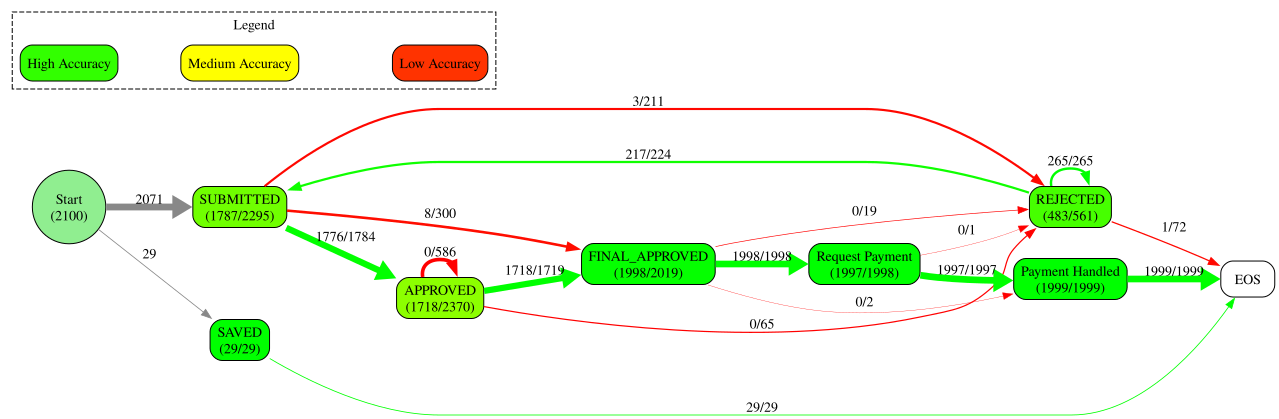

In [11]:
import graphviz
import math

MIN_EDGE_COUNT = 0  # raise to filter rare edges

def get_color_for_accuracy(accuracy: float) -> str:
    """Red (low) -> Yellow (mid) -> Green (high) gradient -- same as henryk/process_performance_map."""
    if accuracy < 0.5:
        r = 255
        g = int(255 * (accuracy * 2))
        b = 0
    else:
        r = int(255 * (1 - (accuracy - 0.5) * 2))
        g = 255
        b = 0
    return f'#{r:02x}{g:02x}{b:02x}'


dot = graphviz.Digraph(comment=f'Camargo {SPEC.name} Process Performance Map')
dot.attr(rankdir='LR')
dot.attr('node', shape='box', style='rounded,filled', fillcolor='white')

for act, s in node_stats.items():
    if s['total'] > 0:
        acc = s['correct'] / s['total']
        label = f"{act}\n({s['correct']}/{s['total']})"
        fill = get_color_for_accuracy(acc)
    else:
        label = str(act)
        fill = 'white'
    dot.node(str(act), label=label, fillcolor=fill)

start_counts = {}
for r in records:
    if r['prefix_length'] == 1:
        start_counts[r['current_activity']] = start_counts.get(r['current_activity'], 0) + 1
total_cases = sum(start_counts.values())
if total_cases:
    dot.node('__START__', label=f'Start\n({total_cases})', shape='circle', fillcolor='#90EE90', style='filled')
    for act, cnt in start_counts.items():
        if cnt >= MIN_EDGE_COUNT:
            dot.edge('__START__', str(act), label=str(cnt), color='#888888',
                     penwidth=str(max(0.3, math.sqrt(cnt) * 0.15)),
                     weight=str(int(math.log1p(cnt) * 10)))

for (src, tgt), s in stats.items():
    if s['total'] < MIN_EDGE_COUNT:
        continue
    acc = s['correct'] / s['total']
    color = get_color_for_accuracy(acc)
    label = f"{s['correct']}/{s['total']}"
    # Edge weight = log(count) so dot's ranker pulls the heaviest path into a
    # straight horizontal trunk; self-loops use constraint=false so they don't
    # shift ranks. Mirrors the henryk PPM visualizer for layout consistency.
    edge_kwargs = {
        'label': label, 'color': color,
        'penwidth': str(max(0.3, math.sqrt(s['total']) * 0.15)),
        'weight': str(int(math.log1p(s['total']) * 10)),
    }
    if src == tgt:
        edge_kwargs['constraint'] = 'false'
    dot.edge(str(src), str(tgt), **edge_kwargs)

with dot.subgraph(name='cluster_legend') as legend:
    legend.attr(label='Legend', style='dashed')
    legend.node('high_acc', 'High Accuracy', fillcolor=get_color_for_accuracy(0.9))
    legend.node('mid_acc', 'Medium Accuracy', fillcolor=get_color_for_accuracy(0.5))
    legend.node('low_acc', 'Low Accuracy', fillcolor=get_color_for_accuracy(0.1))
    legend.edge('high_acc', 'mid_acc', style='invis')
    legend.edge('mid_acc', 'low_acc', style='invis')

dot

In [12]:
# Per-source summary
print('Per-source-activity accuracy:')
for act, s in sorted(node_stats.items(), key=lambda x: -x[1]['total']):
    acc = s['correct'] / s['total']
    print(f"  {act:<30s} {s['correct']:5d}/{s['total']:<5d}  {acc * 100:5.1f}%")

Per-source-activity accuracy:
  APPROVED                        1718/2370    72.5%
  SUBMITTED                       1787/2295    77.9%
  FINAL_APPROVED                  1998/2019    99.0%
  Payment Handled                 1999/1999   100.0%
  Request Payment                 1997/1998    99.9%
  REJECTED                         483/561     86.1%
  SAVED                             29/29     100.0%
